In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [4]:
insurance_data = pd.read_csv('medical_insurance.csv')

In [5]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [7]:
insurance_data.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
insurance_data.shape

(2772, 7)

In [9]:
insurance_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

data distribution for numerical value

C:\Users\sudhanshu  singh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 600x600 with 0 Axes>

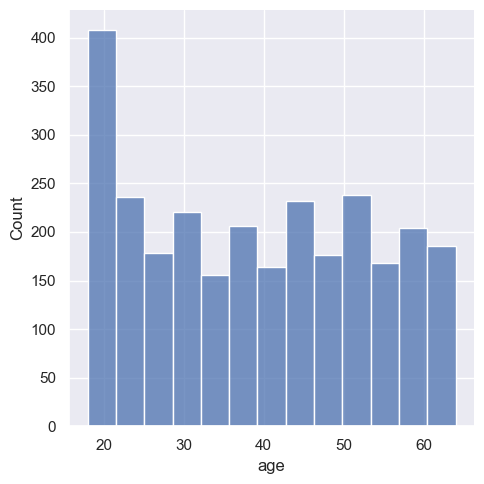

In [10]:
sns.set()
plt.figure(figsize=(6,6))
sns.displot(insurance_data['age'])
plt.show()

In [11]:
insurance_data['age'].value_counts()

age
18    148
19    142
47     62
52     62
45     62
23     62
46     60
54     60
51     60
28     60
21     60
22     60
26     60
25     58
50     58
27     58
20     58
53     58
48     58
49     56
44     56
41     56
24     56
32     56
30     56
56     56
39     54
33     54
42     54
40     54
43     54
31     54
57     54
29     54
37     52
59     52
58     52
34     52
55     52
35     50
36     50
38     50
62     48
60     46
64     46
63     46
61     46
Name: count, dtype: int64

C:\Users\sudhanshu  singh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 600x600 with 0 Axes>

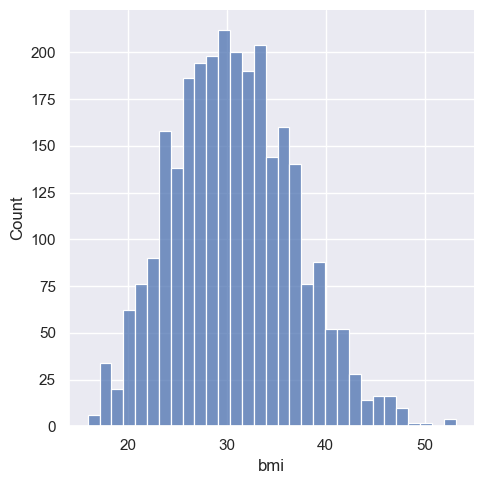

In [12]:
sns.set()
plt.figure(figsize=(6,6))
sns.displot(insurance_data['bmi'])
plt.show()

C:\Users\sudhanshu  singh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 600x600 with 0 Axes>

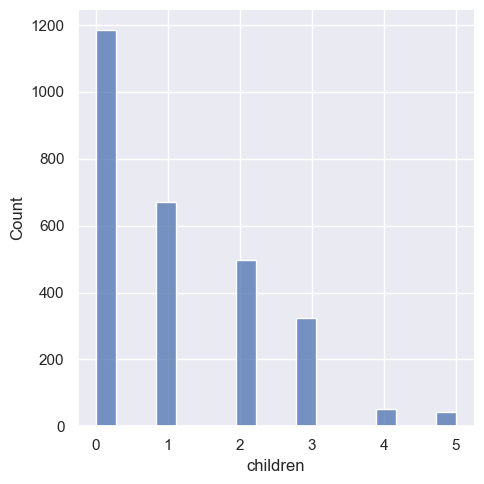

In [13]:
sns.set()
plt.figure(figsize=(6,6))
sns.displot(insurance_data['children'])
plt.show()

categorical column

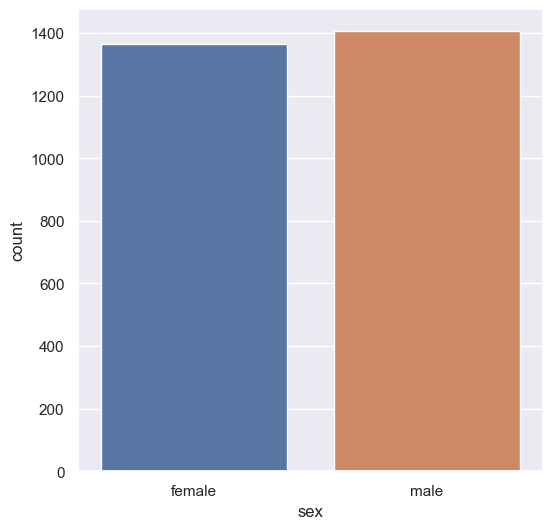

In [14]:
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(x= insurance_data['sex'], data = insurance_data)
plt.show()

In [15]:
insurance_data['sex'].value_counts()

sex
male      1406
female    1366
Name: count, dtype: int64

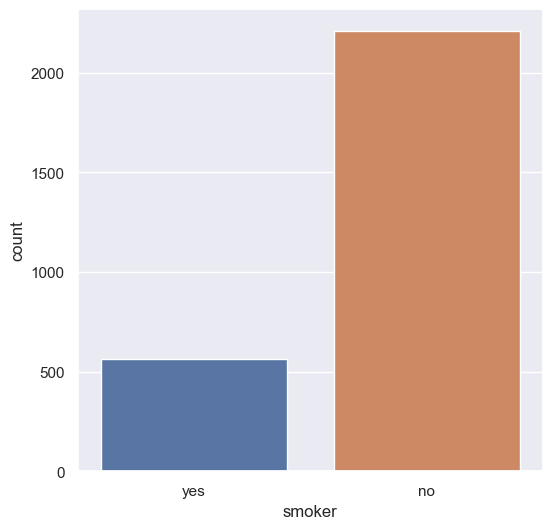

In [16]:
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(x= insurance_data['smoker'], data = insurance_data)
plt.show()

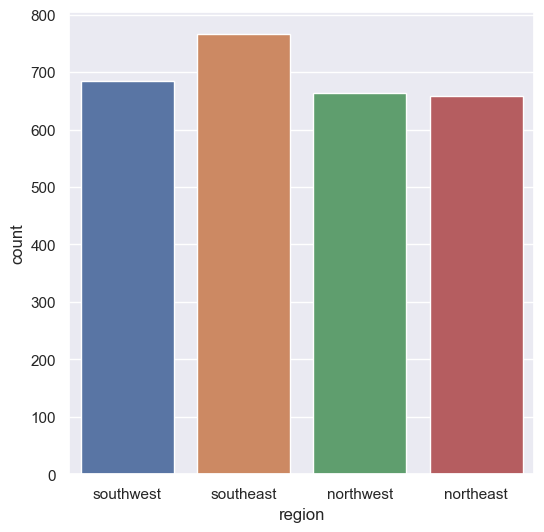

In [17]:
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(x= insurance_data['region'], data = insurance_data)
plt.show()

In [18]:
insurance_data['region'].value_counts()

region
southeast    766
southwest    684
northwest    664
northeast    658
Name: count, dtype: int64

In [19]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


converting categorical column into numerical column

In [20]:
insurance_data.replace({'sex':{'female':0, 'male':1}}, inplace=True)

insurance_data.replace({'smoker':{'no':0, 'yes':1}}, inplace=True)

insurance_data.replace({'region':{'southeast':0, 'southwest':1, 'northeast':2, 'northwest':3}}, inplace=True)

In [21]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,1,16884.92400
1,18,1,33.770,1,0,0,1725.55230
2,28,1,33.000,3,0,0,4449.46200
3,33,1,22.705,0,0,3,21984.47061
4,32,1,28.880,0,0,3,3866.85520
...,...,...,...,...,...,...,...
2767,47,0,45.320,1,0,0,8569.86180
2768,21,0,34.600,0,0,1,2020.17700
2769,19,1,26.030,1,1,3,16450.89470
2770,23,1,18.715,0,0,3,21595.38229


In [22]:
input_data = insurance_data.drop(columns='charges')
output_data = insurance_data['charges']

In [23]:
input_data

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,1
1,18,1,33.770,1,0,0
2,28,1,33.000,3,0,0
3,33,1,22.705,0,0,3
4,32,1,28.880,0,0,3
...,...,...,...,...,...,...
2767,47,0,45.320,1,0,0
2768,21,0,34.600,0,0,1
2769,19,1,26.030,1,1,3
2770,23,1,18.715,0,0,3


In [24]:
output_data

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
2767     8569.86180
2768     2020.17700
2769    16450.89470
2770    21595.38229
2771     9850.43200
Name: charges, Length: 2772, dtype: float64

train test split

In [25]:
input_train_data, input_test_data, output_train_data, output_test_data = train_test_split(input_data, output_data, test_size=0.2)

In [26]:
print(input_data.shape, input_train_data.shape, input_test_data.shape)

(2772, 6) (2217, 6) (555, 6)


In [27]:
print(output_data.shape, output_train_data.shape, output_test_data.shape)

(2772,) (2217,) (555,)


**creating model**

In [28]:
model = RandomForestRegressor(n_estimators=100, max_depth=7)

In [29]:
#Training Model

model.fit(input_train_data, output_train_data)

RandomForestRegressor(max_depth=7)

In [30]:
test_data_predictions = model.predict(input_test_data)

In [31]:
from sklearn.metrics import r2_score

In [32]:
r2_score(test_data_predictions,output_test_data)

0.8883090434826617

In [33]:
#age	sex	bmi	children	smoker	region
input_data = (35, 1,35, 1, 0, 0)
input_data_array = np.asarray(input_data)
input_data_array = input_data_array.reshape(1,-1)

In [34]:
insurance_premium = model.predict(input_data_array)

C:\Users\sudhanshu  singh\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [35]:
insurance_premium[0]

5889.108108312961

In [36]:
import pickle as pkl

In [37]:
pkl.dump(model, open('MIPML.pkl','wb'))